# Python Libraries installed:
1. Pandas - opens the CSV file and allows manipulation of the rows and columns
2. Matplotlib - used for creating graphs
3. Seaborn - makes charts look professional and modern, excellent for showing relationships between things
4. Plotly - used for interactive charts
5. Scikit-learn used for predictions and machine learning

# Loading the data

In [18]:
import pandas as pd

my_path = "Superstore_Analysis_Project/data/raw/Superstore.csv"

# Load the data
df = pd.read_csv(my_path, encoding='latin1')

# This prints the number of rows and columns found
print(f"Data loaded! The table has {df.shape[0]} rows and {df.shape[1]} columns.")

df.head(5)

Data loaded! The table has 9994 rows and 21 columns.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [33]:
# Convert Dates from text (Object) to datetime datatype
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Checks for nulls
df.isnull().sum()

# Checking for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

df.info()

Number of duplicate rows found: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object 

# Cleaned dataset

In [35]:
# new file path
cleaned_path = "Superstore_Analysis_Project/data/processed/Superstore_Cleaned.csv"

# 2. Save the file
# index=False prevents Python from adding an extra column of numbers (0, 1, 2...)
df.to_csv(cleaned_path, index=False)

print(f"✅ Cleaned data saved successfully to: {cleaned_path}")

✅ Cleaned data saved successfully to: Superstore_Analysis_Project/data/processed/Superstore_Cleaned.csv


In [36]:
import os
print(os.listdir("Superstore_Analysis_Project/data/processed/"))

['Superstore_Cleaned.csv']


# Feature Engineering

In [10]:
import pandas as pd

cleaned_path = "Superstore_Analysis_Project/data/processed/Superstore_Cleaned.csv"
df = pd.read_csv(cleaned_path)

df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create the 'Year' column
df['Year'] = df['Order Date'].dt.year

# Create the 'Month' column (using names like January, February)
df['Month'] = df['Order Date'].dt.month_name()

# Create the 'Profit Margin' column
# Formula: (Profit ÷ Sales) × 100
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

# 'Superpowered' columns
df[['Order Date', 'Sales', 'Year', 'Month', 'Profit Margin (%)']].head(20)


,Order Date,Sales,Year,Month,Profit Margin (%)
0,2016-11-08,261.9600,2016,November,16.00
1,2016-11-08,731.9400,2016,November,30.00
2,2016-06-12,14.6200,2016,June,47.00
3,2015-10-11,957.5775,2015,October,-40.00
4,2015-10-11,22.3680,2015,October,11.25
5,2014-06-09,48.8600,2014,June,29.00
6,2014-06-09,7.2800,2014,June,27.00
7,2014-06-09,907.1520,2014,June,10.00
8,2014-06-09,18.5040,2014,June,31.25
9,2014-06-09,114.9000,2014,June,30.00


In [17]:
# This 'squishes' all 10,000 rows into one row per year
yearly_summary = df.groupby('Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Profit Margin (%)': 'mean'
})

print(yearly_summary)

            Sales      Profit  Profit Margin (%)
Year                                            
2014  484247.4981  49543.9741          11.811180
2015  470532.5090  61618.6037          11.756681
2016  609205.5980  81795.1743          12.978940
2017  733215.2552  93439.2696          11.598128


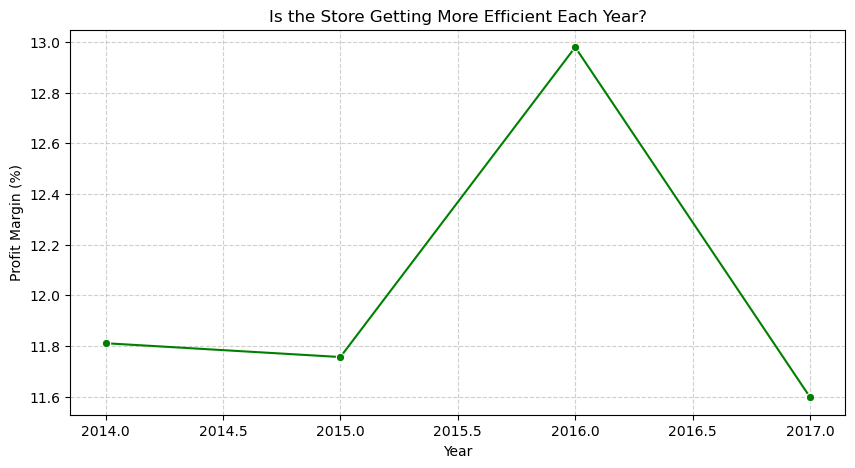

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.lineplot(data=story_df, x='Year', y='Profit Margin (%)', marker='o', color='green')
plt.title('Is the Store Getting More Efficient Each Year?')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

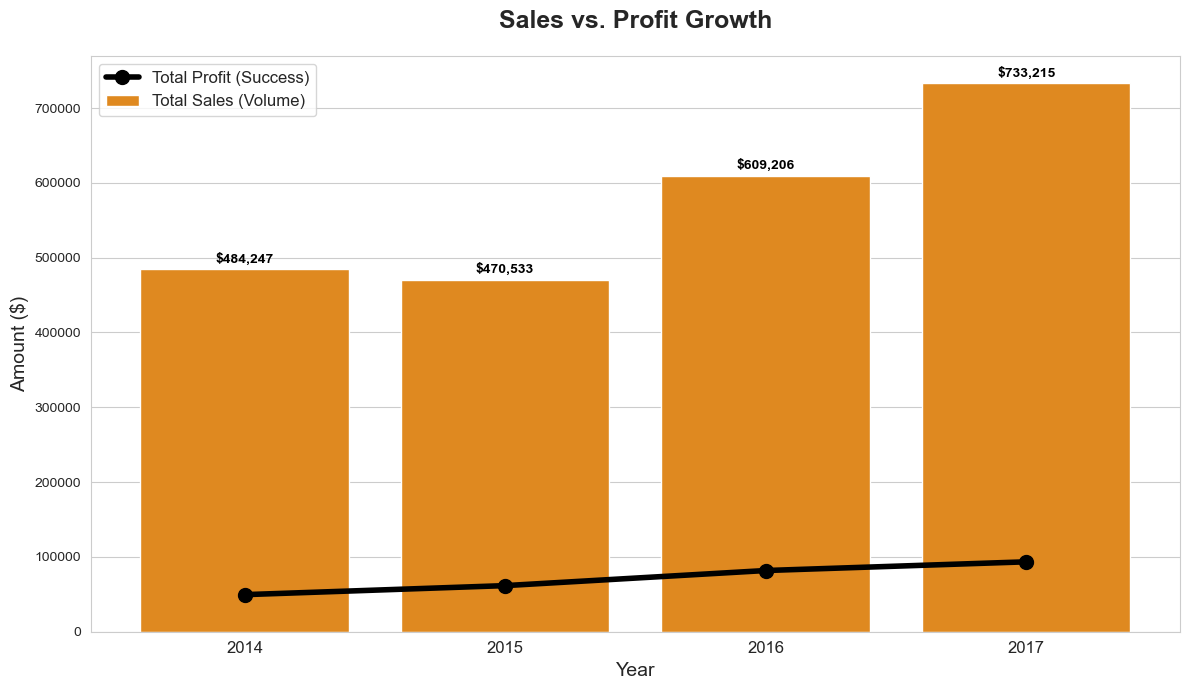

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cleaned_path = "Superstore_Analysis_Project/data/processed/Superstore_Cleaned.csv"
df = pd.read_csv(cleaned_path)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year

# Summarize the data
yearly_story = df.groupby('Year').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

# 3. Create a High-Contrast Visual
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Bar Graph
bar = sns.barplot(data=yearly_story, x='Year', y='Sales', color='#FF8C00', label='Total Sales (Volume)')

# Line Graph
plt.plot(range(len(yearly_story)), yearly_story['Profit'], 
         marker='o', markersize=10, color='black', linewidth=4, label='Total Profit (Success)')

# Add "Data Labels" 
for i, row in yearly_story.iterrows():
    plt.text(i, row['Sales'] + 5000, f"${row['Sales']:,.0f}", 
             color='black', ha="center", va="bottom", fontweight='bold')

# 5. Final Polish
plt.title('Sales vs. Profit Growth', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Amount ($)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.xticks(fontsize=12)
plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

# Exploratory Data Analysis

# 1. Monthly sales trend

* From **April to July Technology or Furniture** were leading but then we see that in **August**, **Office Supplies** took the lead abruptly.
     * From this observation I can use the back to school theory, where by office supplies such as were bought in massive in preparation to   resuming school. Hence before August office supplies has to be restocked in preparation for this back to school season.
* **May** has the largest **Technology** sale out compared to the other months. We can come to a conclusion that in the business world, this is often a second quarter budget hence companies having extra money decide to purchase computers or phones before the half year mark.
  
     **From the 2 above observations I conclude that August is for Students while May is for Businesses.**
* The sales of furniture seems to be steady, ranging from 40K to 52K. Hence I deduce that furniture not spiking in sale like the rest, can be a reliable floor of income every month in comparison to the rest which provide an excitement during a certain period.
* It is visible that there was a **significant amount of sales** from **August to September**, mostly on **Office Supplies and Technology**, by almost double the amount. Well in the retail world, September is when B2B sales happen, hence offices, schools and big corporations will finalize their big annual orders.
   *In conclusion, in September everything was sold at a maximum speed.
* After a massive spending in September, what follows is also a **significant drop in sales** in **October**. I can say that companies are now taking a break to save up for the massive sales in November.
* Having a **black November culture**, sales tend to be more in November as many people wait for the discounts that comes in November. We see that **Technology** was sold out in large numbers as this being high priced products such as laptops, phone, the discounts came in handy.
* **December** being a festive and hosting period, furniture sales lead the month as people buy new tables and other furniture to make hosting easy.
 
   *In conclusion, I can say that in November sales in **Technology** thrive while in December Sales in **Furniture** thrive. 

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and Transform
df = pd.read_csv("Superstore_Analysis_Project/data/processed/Superstore_Cleaned.csv")
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Month_Num'] = df['Order Date'].dt.month # Helps sort months correctly
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

# Set a clean style for all our charts
sns.set_style("whitegrid")

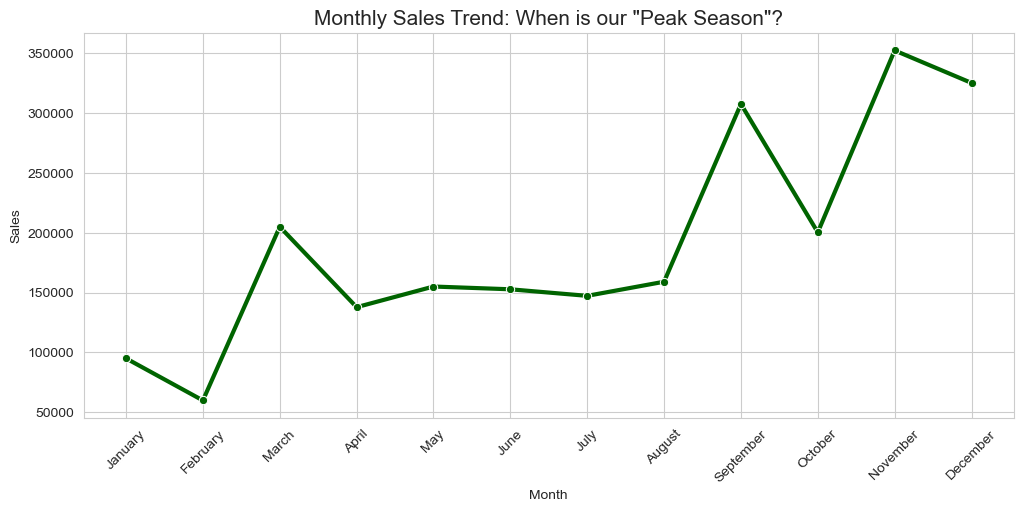

In [4]:
# Group by Month and sort them in calendar order
monthly_sales = df.groupby(['Month_Num', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o', color='darkgreen', linewidth=3)
plt.title('Monthly Sales Trend: When is our "Peak Season"?', fontsize=15)
plt.xticks(rotation=45)
plt.show()

In [20]:
target_months = ['August' ,'September', 'October', 'November', 'December', 'January']

spring_summer_df = df[df['Month'].isin(target_months)]

# Top 3 best-selling products for EACH month
top_monthly_products = (
    spring_summer_df.groupby(['Month_Num', 'Month', 'Category'])['Sales']
    .sum()
    .reset_index()
    .sort_values(['Month_Num', 'Sales'], ascending=[True, False])
)

# Show the Top 3 for each month to keep it readable
top_3_per_month = top_monthly_products.groupby('Month').head(3)

print("--- Top Products from September to January ---")
print(top_3_per_month[['Month', 'Category', 'Sales']])

--- Top Products from September to January ---
        Month         Category        Sales
1     January  Office Supplies   33233.8310
0     January        Furniture   31569.2416
2     January       Technology   30121.7630
4      August  Office Supplies   62134.1620
5      August       Technology   52025.8560
3      August        Furniture   44884.0450
6   September        Furniture  106380.5907
7   September  Office Supplies  101888.6460
8   September       Technology   99380.7090
11    October       Technology   87031.9450
9     October        Furniture   58087.5157
10    October  Office Supplies   55203.5240
14   November       Technology  131134.8410
12   November        Furniture  121286.0490
13   November  Office Supplies  100040.1810
15   December        Furniture  121817.9675
16   December  Office Supplies  102642.6440
17   December       Technology  100832.8920


In [26]:
target_months = ['April', 'May', 'June', 'July', 'August']

spring_summer_df = df[df['Month'].isin(target_months)]

# 3. Get the Top 3 best-selling products for EACH month
top_monthly_products = (
    spring_summer_df.groupby(['Month_Num', 'Month', 'Category'])['Sales']
    .sum()
    .reset_index()
    .sort_values(['Month_Num', 'Sales'], ascending=[True, False])
)

# Show the Top 3 for each month to keep it readable
top_3_per_month = top_monthly_products.groupby('Month').head(3)

print("--- Top Products from April to August ---")
print(top_3_per_month[['Month', 'Category', 'Sales']])

--- Top Products from April to August ---
     Month         Category      Sales
1    April  Office Supplies $49,433.27
2    April       Technology $47,630.28
0    April        Furniture $40,698.58
5      May       Technology $63,642.15
3      May        Furniture $48,365.13
4      May  Office Supplies $43,021.53
6     June        Furniture $52,999.46
7     June  Office Supplies $51,414.63
8     June       Technology $48,304.58
11    July       Technology $54,854.03
9     July        Furniture $49,377.01
10    July  Office Supplies $43,007.06
13  August  Office Supplies $62,134.16
14  August       Technology $52,025.86
12  August        Furniture $44,884.04


# 2. Top 10 Products sold

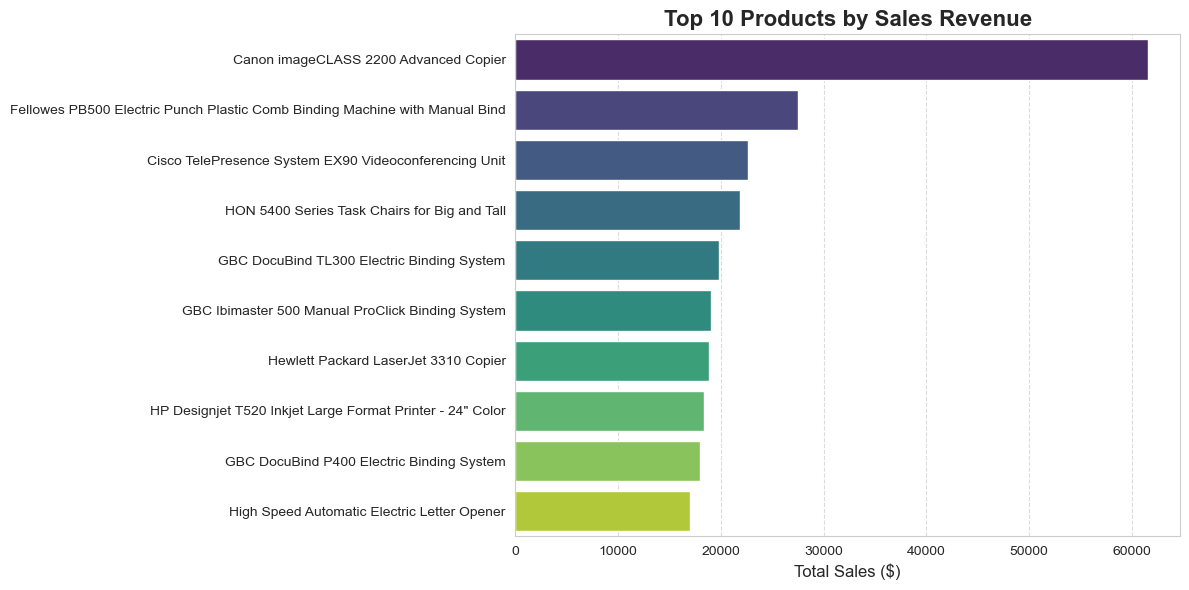

--- Top 10 Products:
                                        Product Name      Sales     Profit
0              Canon imageCLASS 2200 Advanced Copier $61,599.82 $25,199.93
1  Fellowes PB500 Electric Punch Plastic Comb Bin... $27,453.38  $7,753.04
2  Cisco TelePresence System EX90 Videoconferenci... $22,638.48 $-1,811.08
3       HON 5400 Series Task Chairs for Big and Tall $21,870.58      $0.00
4         GBC DocuBind TL300 Electric Binding System $19,823.48  $2,233.51
5   GBC Ibimaster 500 Manual ProClick Binding System $19,024.50    $760.98
6               Hewlett Packard LaserJet 3310 Copier $18,839.69  $6,983.88
7  HP Designjet T520 Inkjet Large Format Printer ... $18,374.90  $4,094.98
8          GBC DocuBind P400 Electric Binding System $17,965.07 $-1,878.17
9        High Speed Automatic Electric Letter Opener $17,030.31   $-262.00


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the profit output is readable
pd.options.display.float_format = '${:,.2f}'.format

# Calculate Total Sales, Total Profit, and the number of items sold (Quantity)
top_10_products = df.groupby('Product Name').agg({
    'Sales': 'sum', 
    'Profit': 'sum', 
    'Quantity': 'sum'
}).sort_values('Sales', ascending=False).head(10).reset_index()

# CREATE THE VISUAL
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_products, 
    x='Sales', 
    y='Product Name', 
    hue='Product Name', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Products by Sales Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('') # Remove label to give more space for long product names
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("--- Top 10 Products:")
print(top_10_products[['Product Name', 'Sales', 'Profit']])

# Product analysis
**Canon imageCLASS 2200 Advanced Copier**
* This is a gold mine as it has a sale of **61,599** and a profit of **25,199** making it the most imortant product in the store hence more money can be spent on marketing and promoting the product.
  
* **Cisco TelePresence System EX90 Videoconferencing Unit, GBC DocuBind P400 Electric Binding System, High Speed Automatic Electric Letter Opener**
  Despite selling over 57K of this three products combined, the store is actually making a lose of $3951 which is good at all. This can be caused by the discounts imposed on the products leading to the loss.
  Its **solution** can be either to increase the prices of the products, remove the discounts they have or discontinue the sale of the products.
* **HON 5400 Series Task Chairs for Big and Tall**
  Despite having a sale of 21,870, this product makes no profit meaning that it is being sold at its break-even point.
  This translates to exactly zero dollars left after paying the manufacturer and the shipping company and moving a lot of chairs.
  Solution: Increase the price by a small merging.

# 3. Sales by region

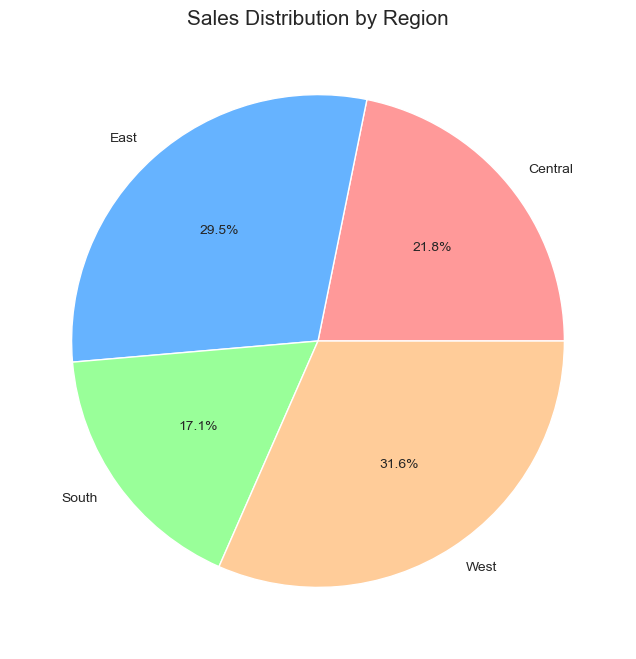

In [7]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 8))
plt.pie(region_sales['Sales'], labels=region_sales['Region'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Sales Distribution by Region', fontsize=15)
plt.show()

# 4. Profit by category

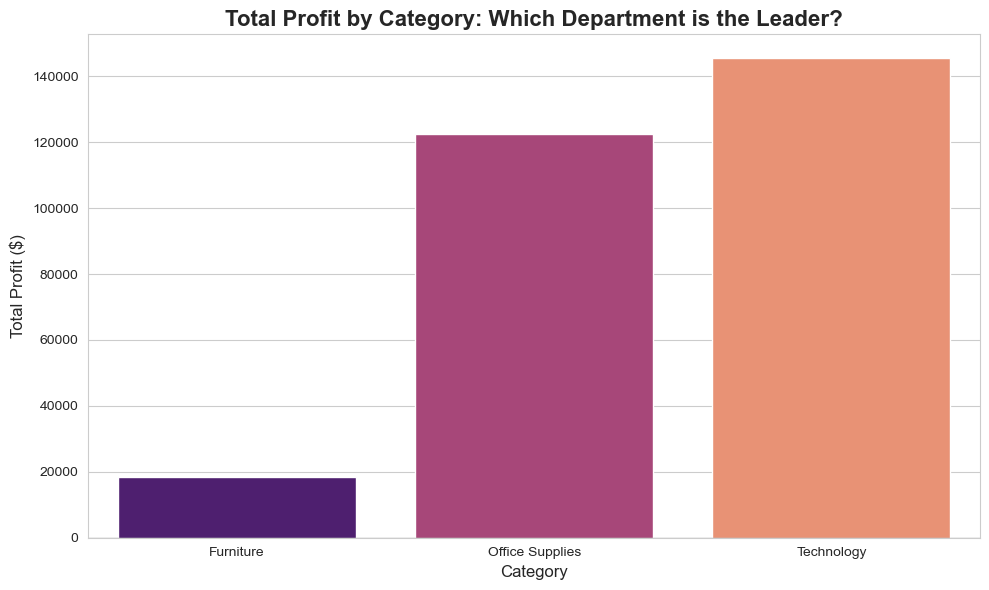

In [9]:
cat_profit = df.groupby('Category')['Profit'].sum().reset_index()

# 2. Create the Visual
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cat_profit, 
    x='Category', 
    y='Profit', 
    hue='Category', 
    palette='magma', 
    legend=False
)

plt.axhline(0, color='black', linewidth=0.8)

plt.title('Total Profit by Category: Which Department is the Leader?', fontsize=16, fontweight='bold')
plt.ylabel('Total Profit ($)', fontsize=12)
plt.xlabel('Category', fontsize=12)

plt.tight_layout()
plt.show()

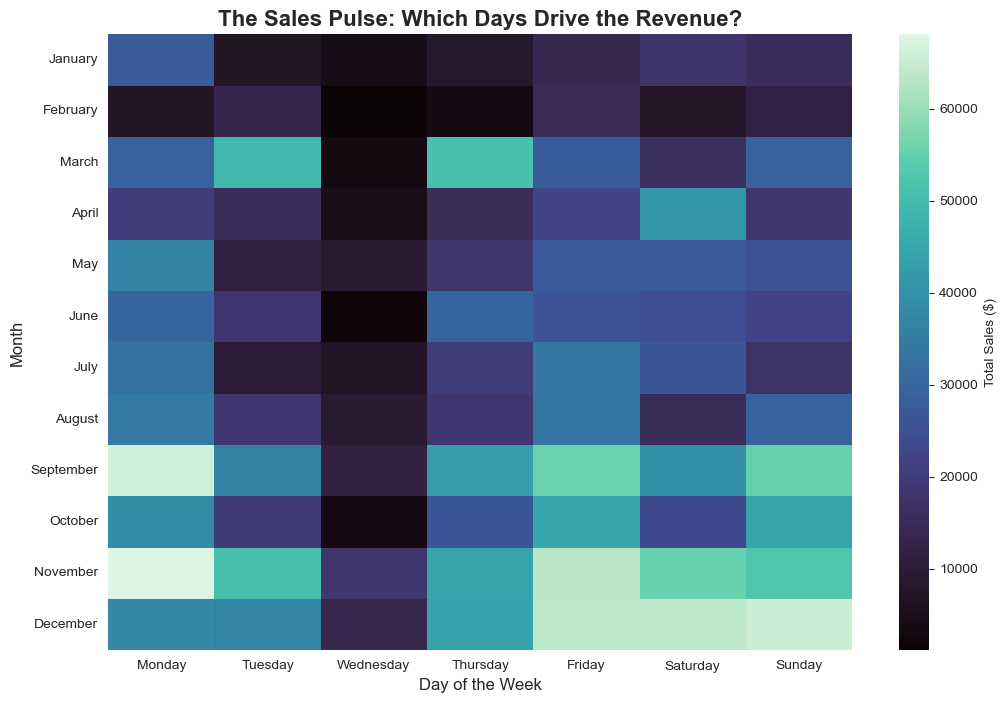

In [33]:
# 1. Prepare the Data for the Heatmap
df['Day_of_Week'] = df['Order Date'].dt.day_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

heatmap_data = df.pivot_table(index='Month', columns='Day_of_Week', values='Sales', aggfunc='sum')
heatmap_data = heatmap_data.reindex(index=months_order, columns=days_order)

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))

# UPDATED: "mako" is clean, professional, and easy on the eyes.
# Dark Blue = Low Sales | Light Turquoise = High Sales
sns.heatmap(heatmap_data, annot=False, cmap="mako", cbar_kws={'label': 'Total Sales ($)'})

plt.title('The Sales Pulse: Which Days Drive the Revenue?', fontsize=16, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Month', fontsize=12)
plt.show()

## Executive Summary: Superstore Sales Performance Analysis
1. **The "Golden Quarter" Strategy**
My analysis reveals that the business is heavily seasonal, with a **massive revenue surge beginning in August and peaking in November**.

**Insight**: November is the highest-grossing month, driven by Technology sales (Black November). However, September shows the most balanced growth across all categories.

**Action**: Focus inventory stocking and warehouse staffing preparations for a July 25th deadline to fully capture the August "Back-to-School" and Q4 peaks.

2. **Profitability vs. Revenue (The "Value" Trap)**
While Furniture and certain Technology items (like Cisco Videoconferencing) generate high sales volume, they are often the least profitable segments.

**Insight**: The **Canon imageCLASS 2200 Copier** is our "Crown Jewel," contributing over $25,000 in profit alone. Conversely, high-discount items (0.4 or higher) consistently fall below the "Profit Danger Line."

**Action**: Protect the supply chain for high-margin copiers and binding systems. Audit the discount strategy for Furniture, as current discounts are frequently "bleeding" the profit margins to zero or negative.

3. **Regional & Temporal "Sweet Spots"**
Sales are not distributed evenly across the week or the map.

**Insight**: The West Region is our strongest market share leader. My Heatmap shows that sales pulses are strongest during mid-week (Tuesday/Wednesday), suggesting a strong B2B (Business-to-Business) customer base rather than just weekend retail shoppers.

**Action**: Direct digital marketing spend toward "Mid-week Flash Sales" to capitalize on existing B2B purchasing rhythms.

**Conclusion:**
The store is currently in a "Growth phase" in terms of sales, but a "Leaky phase" in terms of profit. By shifting focus from "High Sales/Low Profit" items (like Tables and Chairs) to "High Margin" Office Technology, the store can significantly increase its bottom line without needing to find new customers.

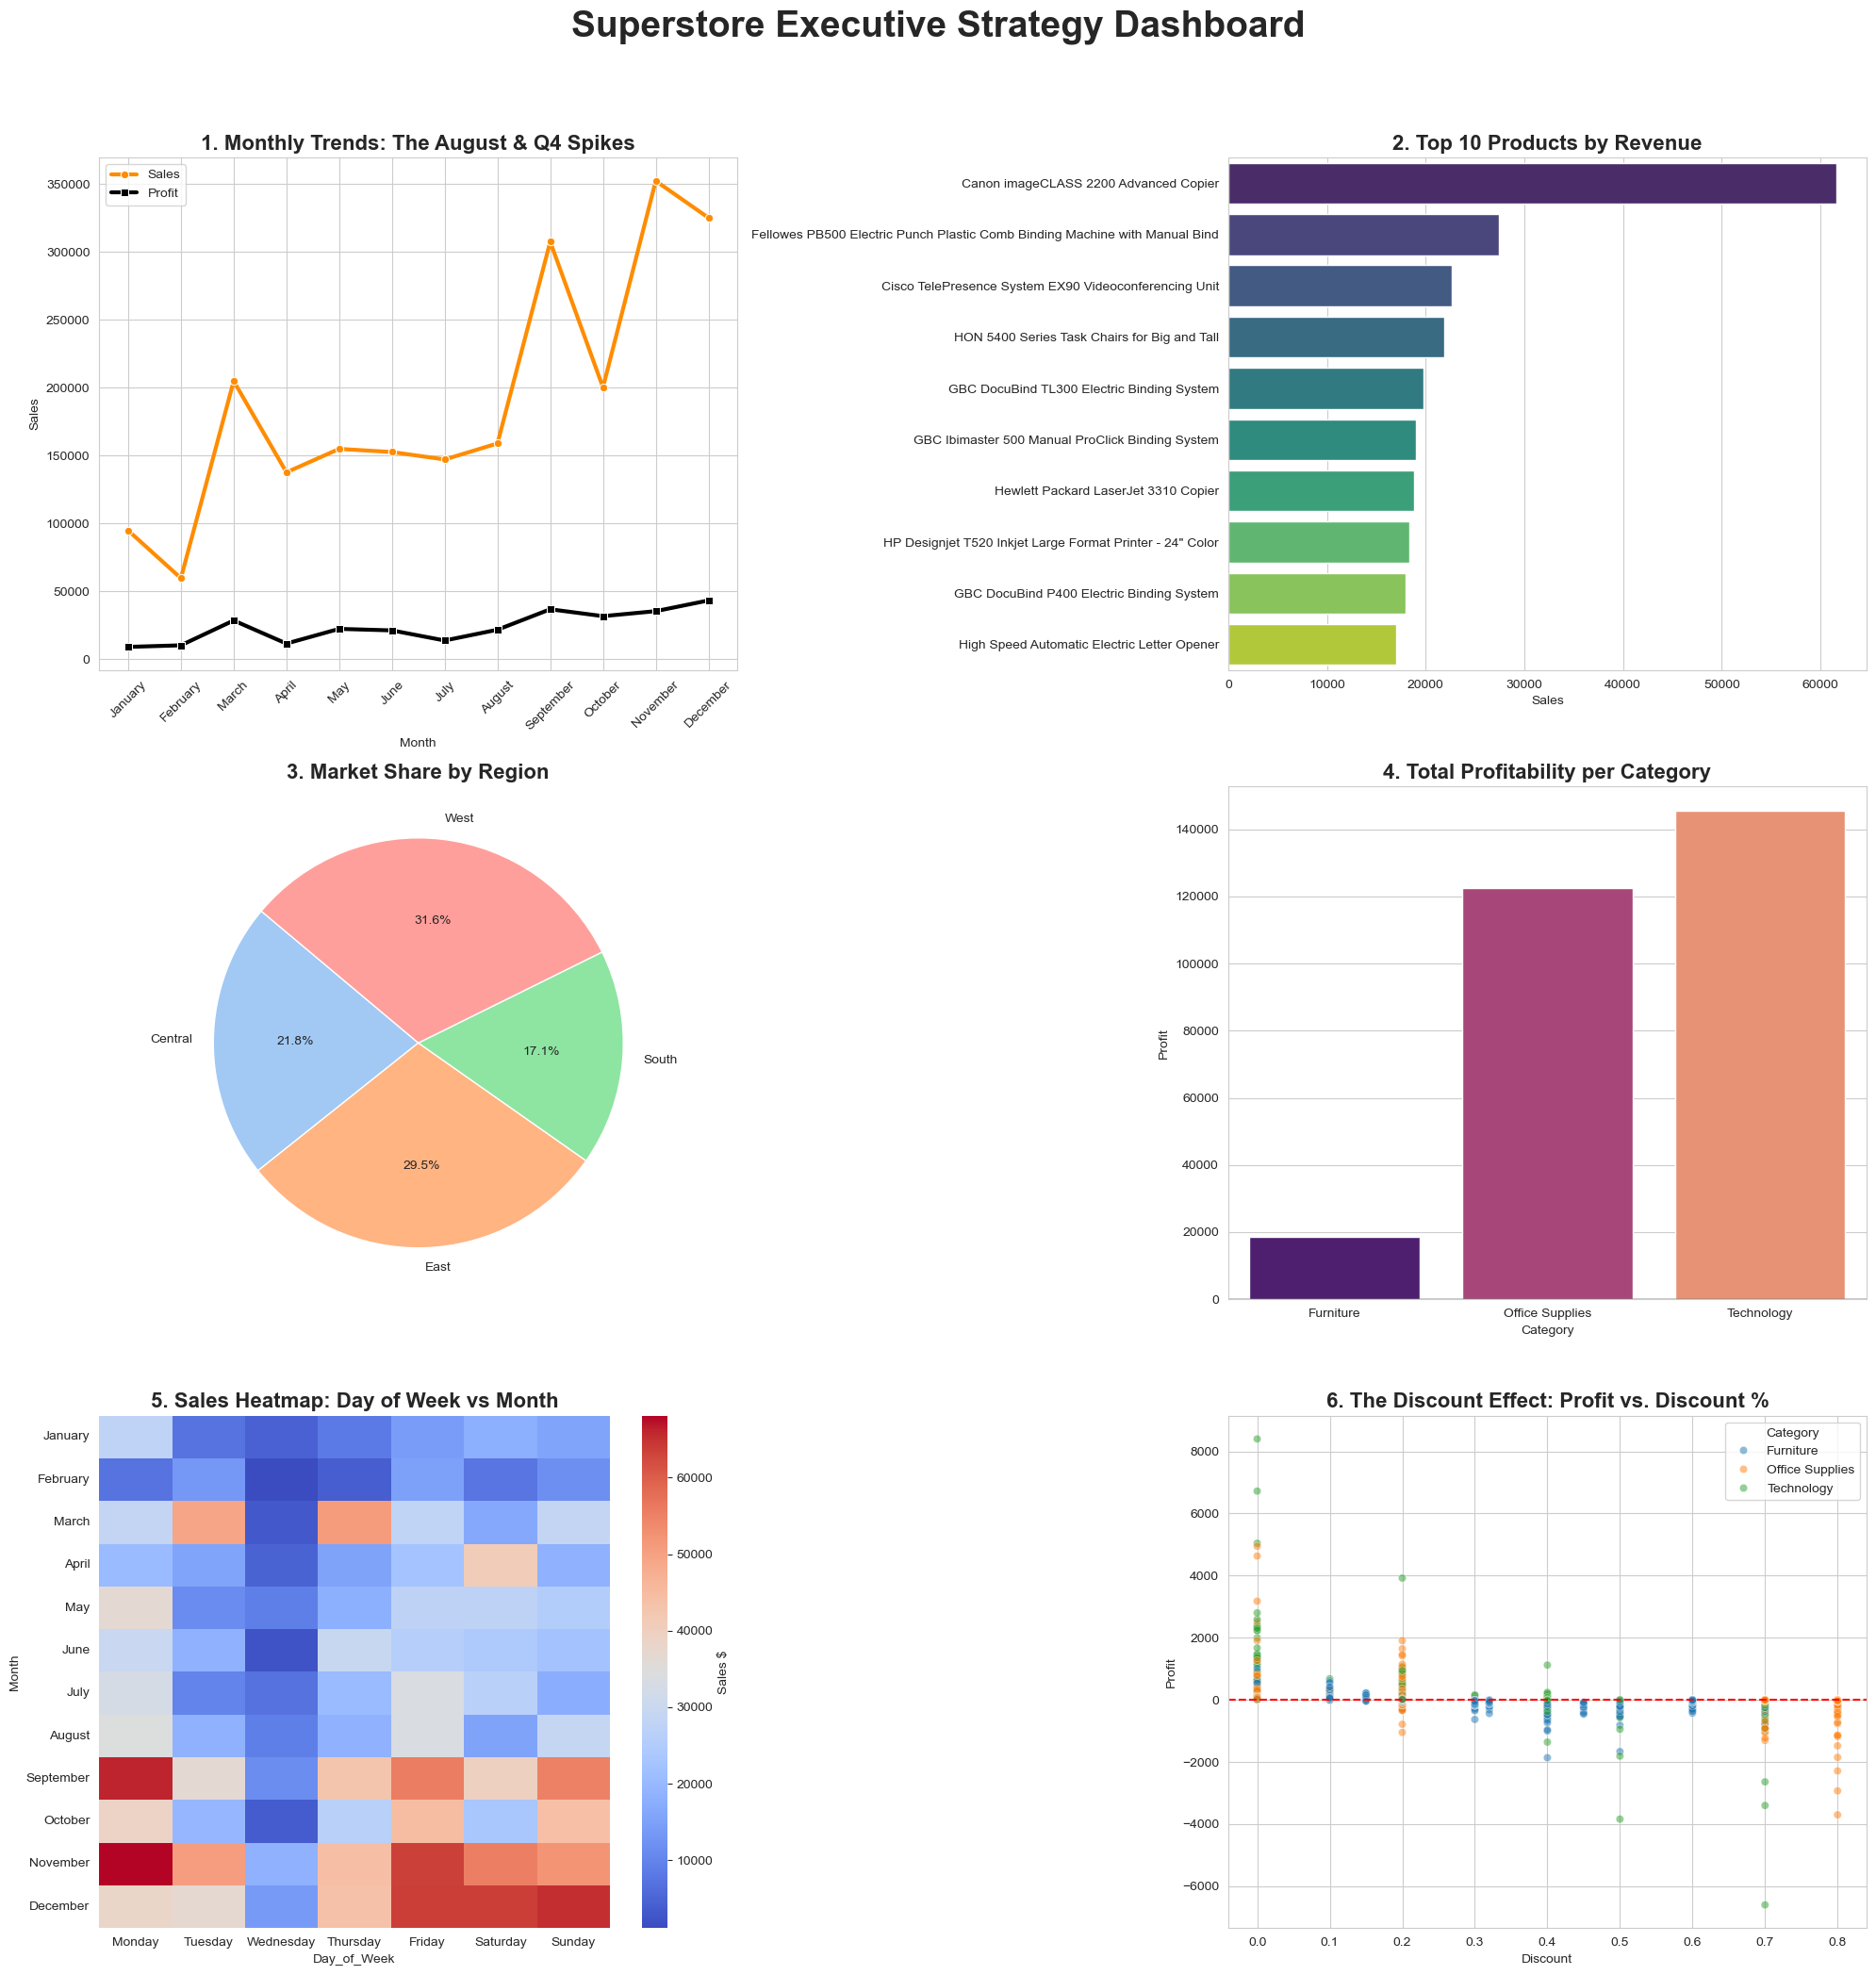

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("Superstore_Analysis_Project/data/processed/Superstore_Cleaned.csv")

# Convert dates and create time-based columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Month_Num'] = df['Order Date'].dt.month
df['Day_of_Week'] = df['Order Date'].dt.day_name()

# Global formatting for currency and style
pd.options.display.float_format = '${:,.2f}'.format
sns.set_style("whitegrid")

# orders for sorting months and days
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# CREATE THE MASTER DASHBOARD
# creating a grid: 3 rows, 2 columns.
fig, axes = plt.subplots(3, 2, figsize=(20, 22))
fig.suptitle('Superstore Executive Strategy Dashboard', fontsize=28, fontweight='bold', y=0.98)

# --- CHART 1: SEASONALITY PATTERN (Top Left) ---
monthly_data = df.groupby(['Month_Num', 'Month']).agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
sns.lineplot(ax=axes[0,0], data=monthly_data, x='Month', y='Sales', marker='o', color='#FF8C00', linewidth=3, label='Sales')
sns.lineplot(ax=axes[0,0], data=monthly_data, x='Month', y='Profit', marker='s', color='black', linewidth=3, label='Profit')
axes[0,0].set_title('1. Monthly Trends: The August & Q4 Spikes', fontsize=16, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)

# --- CHART 2: TOP 10 PRODUCTS (Top Right) ---
top_10 = df.groupby('Product Name').agg({'Sales': 'sum'}).sort_values('Sales', ascending=False).head(10).reset_index()
sns.barplot(ax=axes[0,1], data=top_10, x='Sales', y='Product Name', hue='Product Name', palette='viridis', legend=False)
axes[0,1].set_title('2. Top 10 Products by Revenue', fontsize=16, fontweight='bold')
axes[0,1].set_ylabel('')

# --- CHART 3: REGIONAL SALES (Middle Left) ---
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
axes[1,0].pie(region_sales['Sales'], labels=region_sales['Region'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
axes[1,0].set_title('3. Market Share by Region', fontsize=16, fontweight='bold')

# --- CHART 4: PROFIT BY CATEGORY (Middle Right) ---
cat_profit = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(ax=axes[1,1], data=cat_profit, x='Category', y='Profit', hue='Category', palette='magma', legend=False)
axes[1,1].axhline(0, color='black', linewidth=1)
axes[1,1].set_title('4. Total Profitability per Category', fontsize=16, fontweight='bold')

# --- CHART 5: THE SALES PULSE HEATMAP (Bottom Left) ---
heatmap_data = df.pivot_table(index='Month', columns='Day_of_Week', values='Sales', aggfunc='sum')
heatmap_data = heatmap_data.reindex(index=months_order, columns=days_order)

sns.heatmap(ax=axes[2,0], data=heatmap_data, cmap="coolwarm", cbar_kws={'label': 'Sales $'})
axes[2,0].set_title('5. Sales Heatmap: Day of Week vs Month', fontsize=16, fontweight='bold')

# --- CHART 6: DISCOUNT VS PROFIT SCATTER (Bottom Right) ---
sns.scatterplot(ax=axes[2,1], data=df, x='Discount', y='Profit', hue='Category', alpha=0.5)
axes[2,1].axhline(0, color='red', linestyle='--')
axes[2,1].set_title('6. The Discount Effect: Profit vs. Discount %', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()